In [214]:
import numpy as np
import openmc

uo2 = openmc.Material(name='UO2')
uo2.set_density('g/cm3', 10.5)
uo2.add_nuclide('U235', 0.04, 'wo')
uo2.add_nuclide('U238', 0.84, 'wo')
uo2.add_nuclide('O16',  0.12, 'wo')

b4c = openmc.Material(name='B4C')
b4c.set_density('g/cm3', 2.52)
b4c.add_nuclide('B10',  0.144, 'wo')
b4c.add_nuclide('B11',  0.636, 'wo')
b4c.add_nuclide('C12',  0.22,  'wo')

materials = openmc.Materials([uo2, b4c])

slab_widths = [5.0, 3.0, 5.0, 1.0, 5.0]   # cm
slab_fills  = [uo2, b4c, uo2, b4c, uo2]
x_total     = sum(slab_widths)              # 17 cm

planes = [openmc.XPlane(0.0, boundary_type='reflective')]
x = 0.0
for w in slab_widths:
    x += w
    planes.append(openmc.XPlane(x))
planes[-1].boundary_type = 'reflective'

y_min = openmc.YPlane(-1.0, boundary_type='reflective')
y_max = openmc.YPlane( 1.0, boundary_type='reflective')
z_min = openmc.ZPlane(-1.0, boundary_type='reflective')
z_max = openmc.ZPlane( 1.0, boundary_type='reflective')
yz_region = +y_min & -y_max & +z_min & -z_max

cells = [openmc.Cell(fill=mat, region=+planes[i] & -planes[i+1] & yz_region, name=mat.name) for i, mat in enumerate(slab_fills)]

geometry = openmc.Geometry(openmc.Universe(cells=cells))

settings = openmc.Settings()
settings.run_mode  = 'eigenvalue'
settings.batches   = 50
settings.inactive  = 10
settings.particles = 50_000
settings.source    = openmc.IndependentSource(space=openmc.stats.Box([0.0, -1.0, -1.0], [x_total, 1.0, 1.0]))

slab_tallies = []
for i, (mat, x_lo, x_hi) in enumerate(
        zip(slab_fills,
            [p.x0 for p in planes[:-1]],
            [p.x0 for p in planes[1:]])):

    filt = openmc.SpatialLegendreFilter()
    filt.add_axis('x', order=3, minimum=x_lo, maximum=x_hi)

    t = openmc.Tally(name=f'fet_slab{i}')
    t.filters   = [filt]
    t.scores    = ['flux', 'fission']
    t.estimator = 'collision'
    slab_tallies.append(t)


tallies = openmc.Tallies(slab_tallies)

mesh = openmc.RegularMesh(name='mesh_x')
mesh.dimension   = [100, 1, 1]          # 0.1 cm bins along x
mesh.lower_left  = [0.0,    -1.0, -1.0]
mesh.upper_right = [x_total, 1.0,  1.0]

mesh_tally = openmc.Tally(name='mesh')
mesh_tally.filters   = [openmc.MeshFilter(mesh)]
mesh_tally.scores    = ['flux', 'fission']
mesh_tally.estimator = 'tracklength'
tallies.append(mesh_tally)
model = openmc.model.Model()
model.settings  = settings
model.tallies   = tallies
model.materials = materials
model.geometry  = geometry
model.export_to_model_xml()

In [215]:

openmc.run(openmc_exec="/home/ebny-walid-ahammed/Documents/github/research_project/openmc/build/bin/openmc", output=False)



In [216]:
sp = openmc.StatePoint(f'statepoint.{settings.batches}.h5')
print(f"\nkeff = {sp.keff}")

tally      = sp.get_tally(name=slab_tallies[0].name)
fet_filter = tally.filters[0]
axes       = fet_filter.axes
shape      = tuple(d['order'] + 1 for d in axes)   # (7,) for 1-D order-6

print(f"\nFET axes  : {[d['axis'] for d in axes]}")
print(f"Tensor shape: {shape}")

for score in tally.scores:
    flat = tally.get_values(scores=[score], value='mean').squeeze()
    std  = tally.get_values(scores=[score], value='std_dev').squeeze()

    # Apply Legendre normalization factor (2i+1)/2 to recover true coefficients
    norm = np.array([(2*i + 1) / 2.0 for i in range(shape[0])])
    coeffs     = flat.reshape(shape) * norm
    coeffs_std = std.reshape(shape)  * norm

    print(f"\n{'='*50}")
    print(f"Score: {score}")
    print(f"{'='*50}")
    print(f"  {'i':>3}  {'P_i(x)':>6}  {'coeff':>12}  {'±1σ':>10}")
    print(f"  {'-'*36}")
    for i in range(shape[0]):
        print(f"  {i:>3}  P{i}(x)   {coeffs[i]:+.5e}  {coeffs_std[i]:.3e}")

    # Quick reconstruction sanity check at x = x_total/2
    x_mid  = x_total / 2.0
    xi_mid = 2.0 * (x_mid - 0.0) / x_total - 1.0

    def legendre(order, xi):
        p = np.ones(order + 1)
        if order >= 1: p[1] = xi
        for n in range(1, order):
            p[n+1] = ((2*n+1)*xi*p[n] - n*p[n-1]) / (n+1)
        return p

    P = legendre(shape[0] - 1, xi_mid)
    phi_mid = float(np.dot(coeffs, P))
    print(f"\n  Reconstructed value at x={x_mid:.1f} cm: {phi_mid:.5e}")


keff = 0.45004+/-0.00026

FET axes  : ['x']
Tensor shape: (4,)

Score: flux
    i  P_i(x)         coeff         ±1σ
  ------------------------------------
    0  P0(x)   +8.22621e+00  9.454e-03
    1  P1(x)   -6.17659e-01  8.274e-03
    2  P2(x)   -2.31667e-01  5.921e-03
    3  P3(x)   -1.53488e-02  6.733e-03

  Reconstructed value at x=9.5 cm: 8.34204e+00

Score: fission
    i  P_i(x)         coeff         ±1σ
  ------------------------------------
    0  P0(x)   +2.58575e-02  3.140e-05
    1  P1(x)   -1.91158e-03  3.347e-05
    2  P2(x)   -7.52944e-04  3.386e-05
    3  P3(x)   -9.50110e-05  3.698e-05

  Reconstructed value at x=9.5 cm: 2.62340e-02


In [217]:
def legendre_basis(order, xi):
    p = np.ones((order + 1, len(xi)))
    if order >= 1:
        p[1] = xi
    for n in range(1, order):
        p[n+1] = ((2*n+1)*xi*p[n] - n*p[n-1]) / (n+1)
    return p

def reconstruct(coeffs, std_devs, axis_def, x_grid, Ly=2.0, Lz=2.0):
    mn, mx = axis_def['minimum'], axis_def['maximum']
    xi    = 2.0 * (x_grid - mn) / (mx - mn) - 1.0
    order = axis_def['order']
    P     = legendre_basis(order, xi)
    norm  = np.array([(2*i+1)/2.0 for i in range(order+1)]) * (2.0 / (mx - mn)) 
    a, a_std = coeffs * norm, std_devs * norm
    return a @ P, np.sqrt((a_std**2) @ P**2)


boundaries  = np.cumsum([0] + slab_widths)     # [0, 5, 6, 11, 12, 17]
labels      = ['UO2', 'B4C', 'UO2', 'B4C', 'UO2']
colors      = ['#ffe0b2', '#b3e5fc', '#ffe0b2', '#b3e5fc', '#ffe0b2']
scores      = ['flux', 'fission']

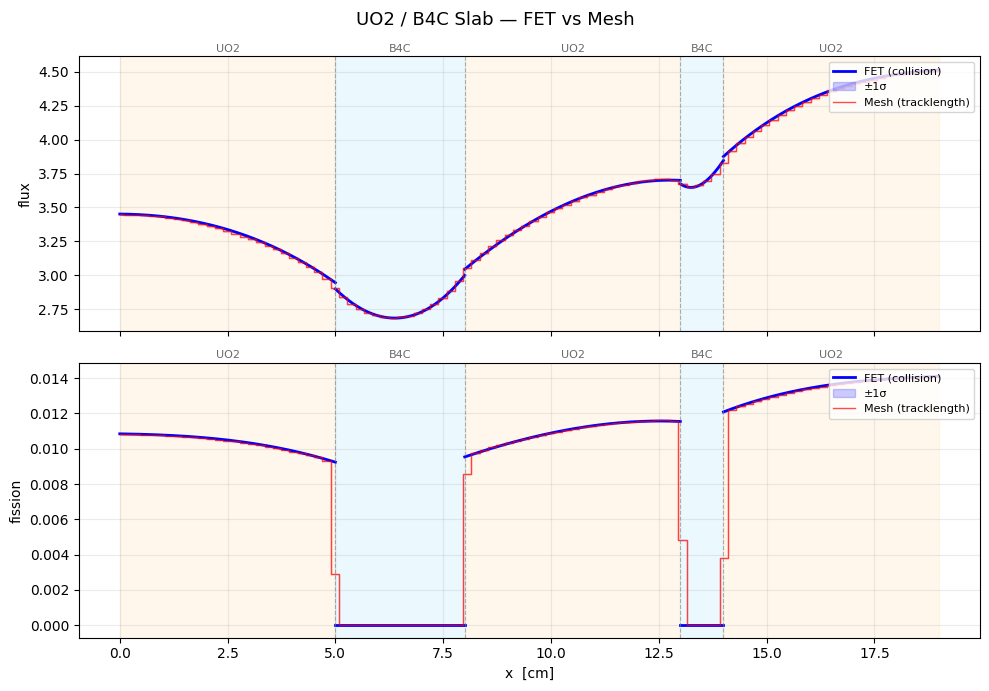

In [218]:


with openmc.StatePoint('statepoint.50.h5') as sp:

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    fig.suptitle('UO2 / B4C Slab — FET vs Mesh', fontsize=13)

    # --- mesh reference (read once, plot on both axes) ----------------------
    mesh_tally = sp.get_tally(name='mesh')
    n_bins     = mesh.dimension[0]
    x_mesh     = np.linspace(0.0, sum(slab_widths), n_bins)

    dx        = sum(slab_widths) / n_bins  
    cell_vol  = dx           

        # --- per-slab FET -------------------------------------------------------
    for idx, slab_tally in enumerate(slab_tallies):
        tally  = sp.get_tally(name=slab_tally.name)
        filt   = tally.filters[0]
        ax_def = filt.axes[0]
        x_grid = np.linspace(ax_def['minimum'], ax_def['maximum'], 200)

        for ax, score in zip(axes, scores):
            mean = tally.get_values(scores=[score], value='mean').squeeze()
            std  = tally.get_values(scores=[score], value='std_dev').squeeze()
            phi, phi_unc = reconstruct(mean, std, ax_def, x_grid)

            first = (idx == 0)
            ax.plot(x_grid, phi, 'b-', lw=2,
                    label='FET (collision)' if first else None)
            ax.fill_between(x_grid, phi - phi_unc, phi + phi_unc,
                            color='blue', alpha=0.2,
                            label='±1σ' if first else None)
    mesh_data = {}
    for score in scores:
        mesh_data[score]          = mesh_tally.get_values(scores=[score], value='mean').squeeze().reshape(n_bins) / cell_vol
        mesh_data[score + '_std'] = mesh_tally.get_values(scores=[score], value='std_dev').squeeze().reshape(n_bins) / cell_vol

    for ax, score in zip(axes, scores):
        ax.plot(x_mesh, mesh_data[score], 'r-',
                lw=1, drawstyle='steps-mid', label='Mesh (tracklength)', alpha=0.7)
        ax.fill_between(x_mesh,
                        mesh_data[score] - mesh_data[score+'_std'],
                        mesh_data[score] + mesh_data[score+'_std'],
                        step='mid', color='red', alpha=0.15)


    # --- shared decorations -------------------------------------------------
    for ax, score in zip(axes, scores):
        for i, (x0, x1) in enumerate(zip(boundaries[:-1], boundaries[1:])):
            ax.axvspan(x0, x1, color=colors[i], alpha=0.25)
            ax.text((x0+x1)/2, 1.01, labels[i], ha='center', va='bottom',
                    fontsize=8, color='dimgray',
                    transform=ax.get_xaxis_transform())
        for xb in boundaries[1:-1]:
            ax.axvline(xb, color='gray', lw=0.8, ls='--', alpha=0.6)
        ax.set_ylabel(score)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel('x  [cm]')
    plt.tight_layout()
    plt.show()